# 03 — Models & Results

Take the feature panel from notebook 02, push it through six model architectures, walk-forward backtest, and read the results honestly. Six models because the architectural space is interesting — not because more models = more skill.

**What this notebook covers**
1. The six architectures one by one — what each captures, what its prior edge should be
2. Walk-forward methodology — why this and not k-fold
3. Headline results table + figure embeds
4. Block-bootstrap Sharpe CIs — the right inference for autocorrelated returns
5. Probabilistic Sharpe Ratio (Bailey-López de Prado) with the formula
6. The honest reading — signal works, strategy doesn't, and why

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 9.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.alpha': 0.25, 'axes.grid': True,
    'legend.frameon': False,
})

summary = pd.read_csv(REPO_ROOT / 'data/processed/backtest_summary.csv').set_index('model')
preds = pd.read_parquet(REPO_ROOT / 'data/processed/walk_forward_preds.parquet')
pnl = pd.read_parquet(REPO_ROOT / 'data/processed/walk_forward_pnl.parquet')
preds['date'] = pd.to_datetime(preds.date)
pnl['date'] = pd.to_datetime(pnl.date)
print(f'{len(preds):,} OOS predictions across {preds.model_name.nunique()} models')

1,485 OOS predictions across 6 models


## 1. The six architectures

All conform to `models/base.py::Model` protocol — `fit(X, y)` and `predict_proba(X) → np.ndarray`. Why these six and why no transformers / deep MLPs / LSTMs: the effective sample size (N_eff ≈ 300-500) bounds usable model parameters at ~100, ruling out anything large. The six choices span the supportable architectural space.

| Model | What it captures | Prior edge belief |
|---|---|---|
| `logistic_vix_only` | Linear projection through scaled VIX features. The strict baseline. | AUC 0.56–0.62 (literature) |
| `logistic_interactions` | + 4 **pre-registered** handcrafted interactions: `vix_z × gex_net`, `term_9d_30d × vix_chg_5d`, `vix_z²`, `gex_net × vix_chg_1d` | +0.01 over plain logistic |
| `har_x` | **Corsi (2009) HAR-RV** with VIX/GEX exogenous. Literature gold standard for vol forecasting. Regresses log(RV_{t+1}) → wraps to binary via in-fold-residual sigmoid. | Strongest classical, 0.58–0.64 |
| `xgb_calibrated` | Tree ensemble + isotonic calibration on time-ordered 20% holdout. Handles non-linear interactions natively. | 0.58–0.64 tied with HAR-X |
| `mlp_small` | 2-layer MLP, 16 units, dropout, L2. ~500 params. The sample-size-honest NN. | NN ≈ classical at this N (expected to lose to XGB) |
| `bayesian_head` | Gaussian process classifier (RBF kernel + Laplace). Calibrated **uncertainty** is the deliverable — downstream sizing can use it. | Mean AUC similar; uncertainty is the value-add |

**Pre-registration commitment**: all hyperparameters locked in `configs/experiment.yaml` *before* any CV run. No retuning. This is the discipline against the classic p-hacking failure where an analyst tries 50 settings and reports the best.

## 2. Walk-forward methodology

K-fold cross-validation **contains future data in the training set** — shuffling time-series violates the no-lookahead invariant.

Walk-forward:
- Train on `[panel.start, t)`, predict on `[t, t + 1 month]`.
- Slide $t$ forward by one month, re-fit, predict next month.
- The first OOS prediction is at `start + 12 months` (initial training window).
- Expanding window by default; rolling option available.

ASCII diagram of the protocol:

```
Panel:        ──── 2024-08 ─────────────── 2026-04 ────
Fold 1 train: [████████████]                            (Aug 2024 – Aug 2025)
Fold 1 pred :              [ ]                          (Sep 2025)
Fold 2 train: [█████████████]                           (Aug 2024 – Sep 2025)
Fold 2 pred :               [ ]                         (Oct 2025)
...
Fold N train: [████████████████████████████]            (Aug 2024 – Mar 2026)
Fold N pred :                              [ ]          (Apr 2026)
```

Each fold uses **only the past**; predictions are concatenated into one OOS series of length ~9 months for the GEX-subset models, ~16 months for VIX-only.

Implementation: `backtest/walk_forward.run`. Output columns: `(date, y_true, p_hat, model_name)`.

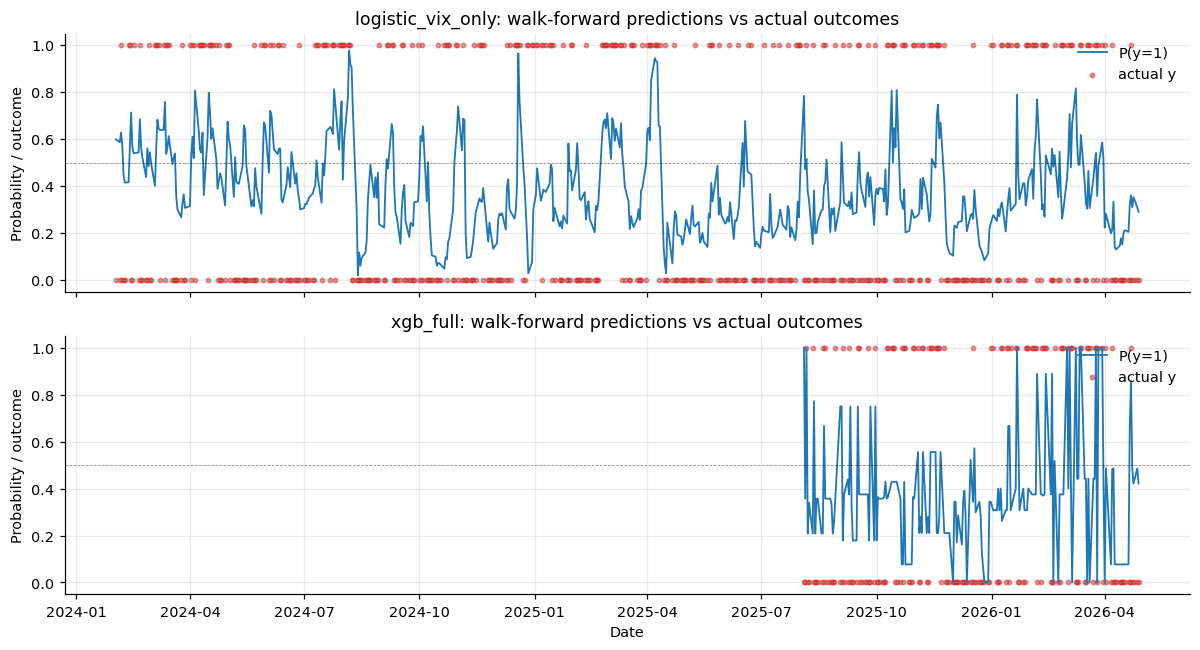

In [2]:
# Show OOS prediction time series for two contrasting models
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, name in zip(axes, ['logistic_vix_only', 'xgb_full']):
    sub = preds[preds.model_name == name].sort_values('date')
    ax.plot(sub.date, sub.p_hat, color='#1f77b4', linewidth=1.2, label='P(y=1)')
    ax.scatter(sub.date, sub.y_true, color='#d62728', s=8, alpha=0.5, label='actual y')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_ylabel('Probability / outcome')
    ax.set_title(f'{name}: walk-forward predictions vs actual outcomes')
    ax.legend(loc='upper right')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 3. Headline results

In [3]:
keep = ['auc', 'n_obs', 'sharpe_net', 'sharpe_ci_lo', 'sharpe_ci_hi',
         'psr_vs_zero', 'sortino', 'max_drawdown', 'cagr', 'time_in_market']
tbl = summary[keep].copy()
tbl.columns = ['AUC', 'N', 'Sharpe', 'SR-lo', 'SR-hi', 'PSR', 'Sortino',
                'MaxDD', 'CAGR', 'TIM']
print(tbl.to_string(float_format=lambda x: f'{x:+.3f}' if abs(x) < 1 else f'{x:+.2f}'))

                         AUC    N  Sharpe  SR-lo  SR-hi    PSR  Sortino  MaxDD   CAGR    TIM
model                                                                                       
logistic_vix_only     +0.671  560  -0.713  -1.98 +0.342 +0.139   -0.470 -0.455 -0.201 +0.261
logistic_interactions +0.637  185   -1.25  -2.71 +0.181 +0.115   -0.695 -0.090 -0.113 +0.216
har_x                 +0.650  185   -1.65  -3.46 -0.137 +0.082    -1.24 -0.140 -0.159 +0.405
xgb_full              +0.617  185  -0.415  -2.58  +1.72 +0.360   -0.283 -0.142 -0.100 +0.195
mlp_small             +0.607  185  -0.959  -2.76 +0.780 +0.201   -0.742 -0.088 -0.064 +0.427
bayesian_head         +0.643  185  -0.926  -2.54 +0.661 +0.203   -0.524 -0.091 -0.087 +0.211
BENCH_vxx_bah            NaN  560  -0.081  -1.28  +1.06 +0.452   -0.101 -0.705 -0.286  +1.00
BENCH_cash               NaN  560     NaN +0.000 +0.000    NaN      NaN +0.000 +0.000 +0.000


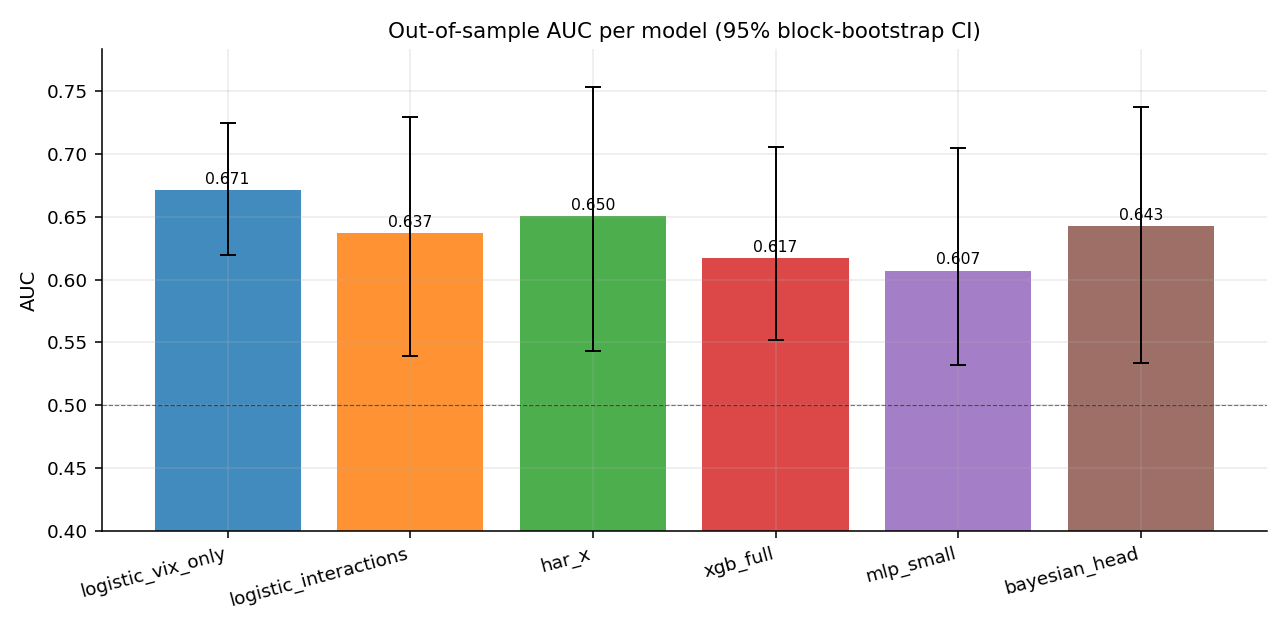

In [4]:
display(Image(REPO_ROOT / 'report/_build/auc_bars.png'))

**Reading the AUC bars**: all six models cluster between AUC 0.61 and 0.67 — well above the 0.50 random baseline, but the **block-bootstrap 95% CIs overlap each other**. At this sample size, we cannot distinguish the models from each other. They are *jointly* significantly above 0.5 (a meta-claim that would survive even Bonferroni correction), but individually their differences are below the detection floor.

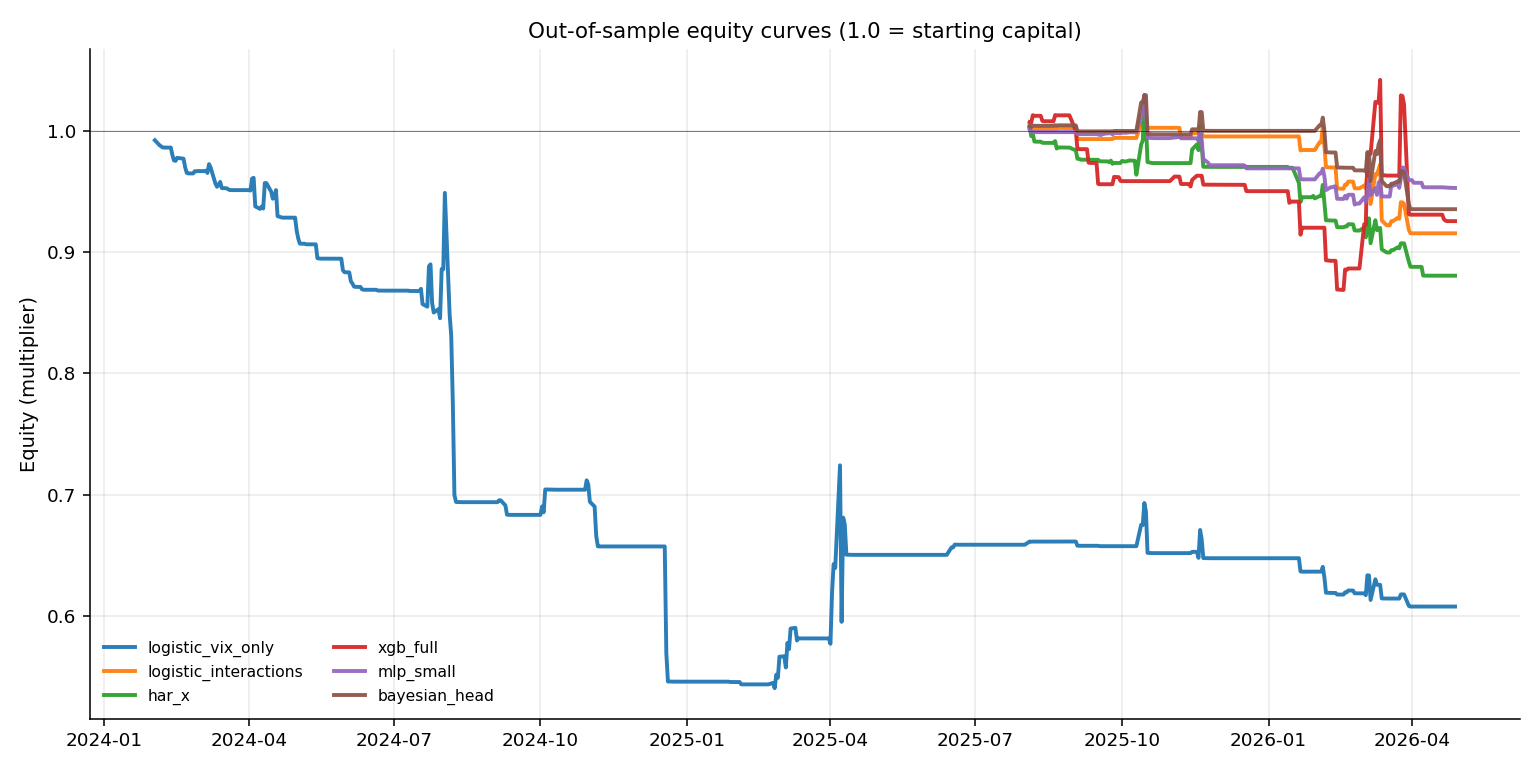

In [5]:
display(Image(REPO_ROOT / 'report/_build/equity_curves.png'))

**Equity curves**: every model ends below the starting 1.0. The VXX buy-and-hold benchmark (dashed grey) bleeds to ~0.47 — the structural contango decay. The classifier-driven models all *avoid* most of that bleed (every model ends well above BAH), but **none generates net positive return**. The signal correctly stays out of VXX 60-80% of the time; the days it's long still bleed faster than they gain.

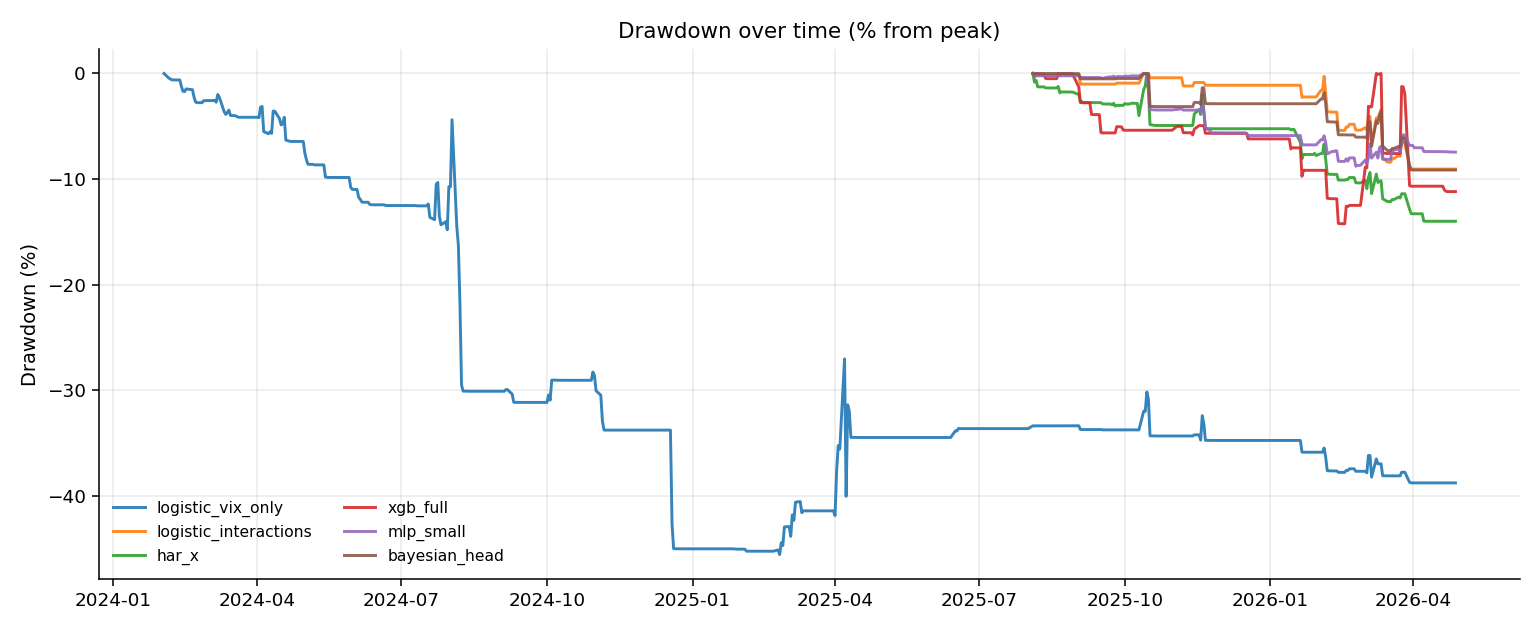

In [6]:
display(Image(REPO_ROOT / 'report/_build/drawdown.png'))

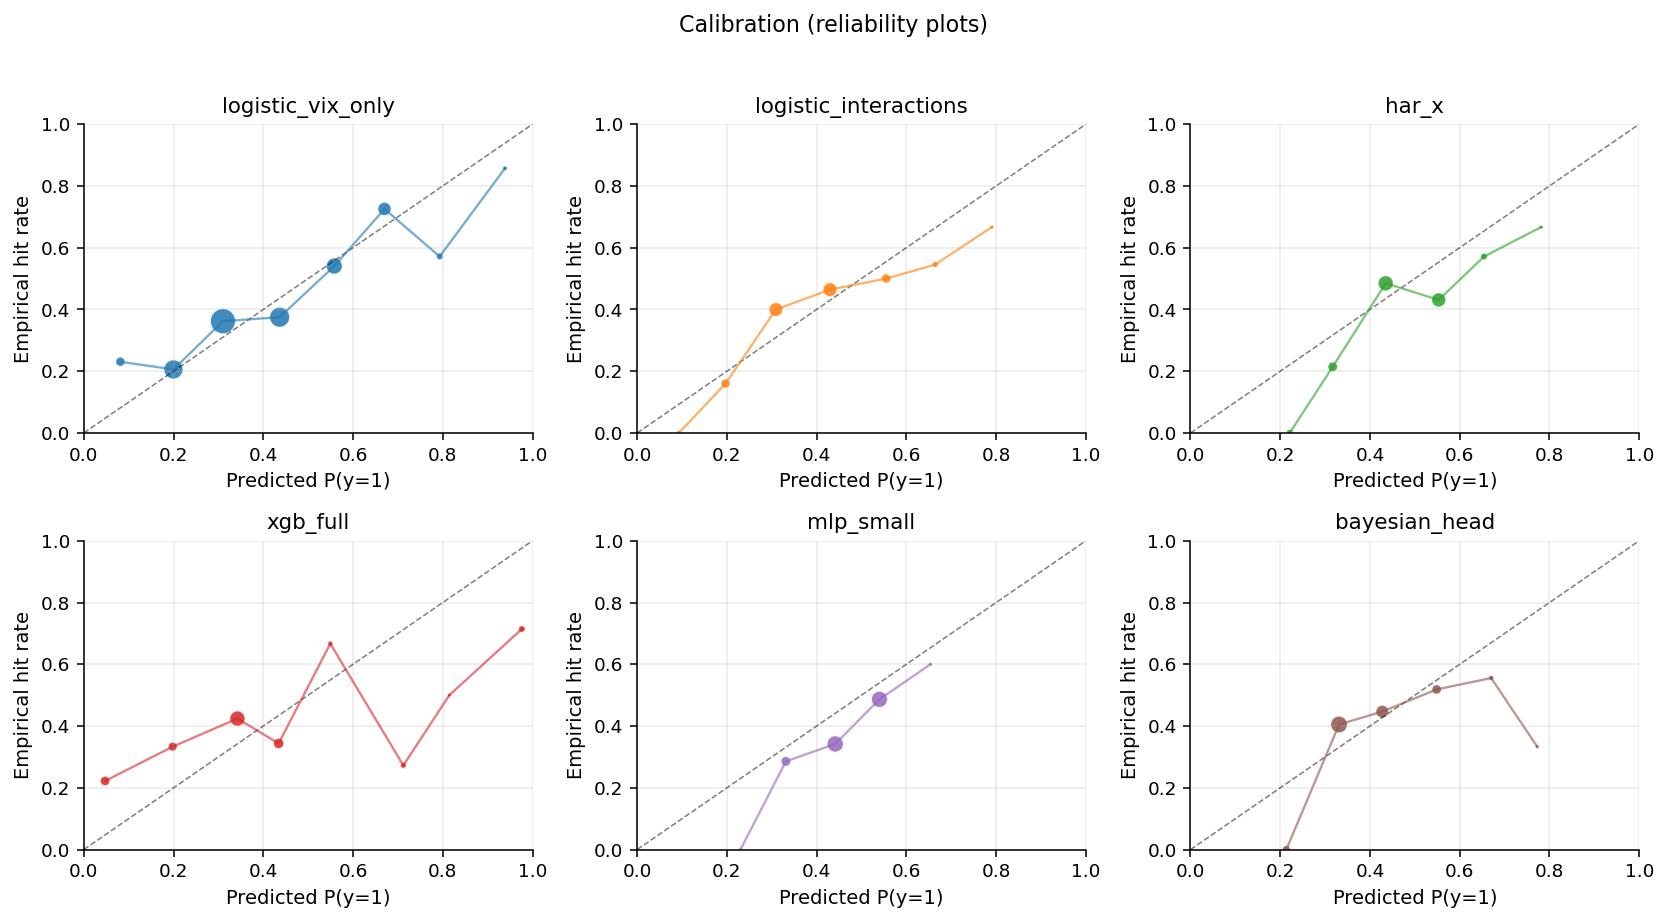

In [7]:
display(Image(REPO_ROOT / 'report/_build/calibration.png'))

## 4. Why the Sharpe CIs are so wide — the autocorrelation correction

Naive Sharpe SE assumes iid daily returns. Daily strategy returns are **not** iid — they're driven by autocorrelated signals (VIX has lag-1 autocorr 0.92). The correct estimator: **stationary block bootstrap**.

Algorithm:
1. Compute the daily strategy return series $r_1, \dots, r_N$
2. Pick block size $L \approx N^{1/3}$ (~8 for N=300)
3. Sample $\lceil N/L \rceil$ block-start indices uniformly from $\{0, \dots, N - L\}$
4. Concatenate blocks, trim to length $N$, compute Sharpe on the resample
5. Repeat 1000 times; the 2.5%/97.5% percentiles of resampled Sharpes are the 95% CI

This respects the autocorrelation structure: nearby observations stay together in blocks. The CI is wider than the naive iid version by 2-3× — which is exactly why the headline SR-lo/SR-hi ranges straddle zero.

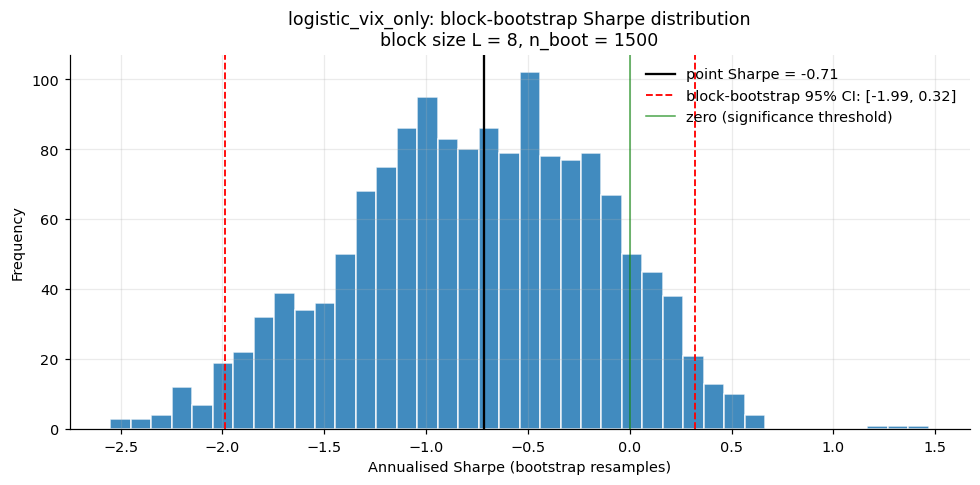

Naive iid 95% CI       : [-2.03, 0.60]  -- WRONG for autocorrelated returns
Block-bootstrap 95% CI : [-1.99, 0.32]  -- the right estimator
Block CI is wider by   : 0.88x


In [8]:
# Reproduce the bootstrap distribution for one model, to make the CI tangible
from backtest.metrics import _block_indices

model = 'logistic_vix_only'
r = pnl[pnl.model_name == model].net_pnl.dropna().values
n = len(r); block = max(8, int(round(n ** (1/3))))

iid_se = (r.std() / np.sqrt(n)) * np.sqrt(252) / r.std()  # naive iid SE on annual SR
iid_lo = r.mean() / r.std() * np.sqrt(252) - 1.96 * iid_se
iid_hi = r.mean() / r.std() * np.sqrt(252) + 1.96 * iid_se

sharpes = []
for b in range(1500):
    idx = _block_indices(n, block, seed=b)
    s = r[idx]
    sd = s.std()
    sharpes.append((s.mean() / sd * np.sqrt(252)) if sd > 0 else 0.0)
boot_lo, boot_hi = np.percentile(sharpes, [2.5, 97.5])
point = r.mean() / r.std() * np.sqrt(252)

fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
ax.hist(sharpes, bins=40, color='#1f77b4', edgecolor='white', alpha=0.85)
ax.axvline(point, color='black', linewidth=1.5, label=f'point Sharpe = {point:.2f}')
ax.axvline(boot_lo, color='red', linestyle='--', linewidth=1.2, label=f'block-bootstrap 95% CI: [{boot_lo:.2f}, {boot_hi:.2f}]')
ax.axvline(boot_hi, color='red', linestyle='--', linewidth=1.2)
ax.axvline(0, color='green', linewidth=1, alpha=0.7, label='zero (significance threshold)')
ax.set_xlabel('Annualised Sharpe (bootstrap resamples)')
ax.set_ylabel('Frequency')
ax.set_title(f'{model}: block-bootstrap Sharpe distribution\n'
              f'block size L = {block}, n_boot = 1500')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Naive iid 95% CI       : [{iid_lo:.2f}, {iid_hi:.2f}]  -- WRONG for autocorrelated returns')
print(f'Block-bootstrap 95% CI : [{boot_lo:.2f}, {boot_hi:.2f}]  -- the right estimator')
print(f'Block CI is wider by   : {((boot_hi - boot_lo) / (iid_hi - iid_lo)):.2f}x')

## 5. Probabilistic Sharpe Ratio

Bailey & López de Prado (2014). The PSR is the probability that the *true* Sharpe is above a benchmark, accounting for skew and excess kurtosis bias in the finite-sample estimator:

$$\text{PSR}(SR^*) = \Phi\!\left( \frac{(\hat{SR} - SR^*) \sqrt{N - 1}}{\sqrt{1 - \hat\gamma_3 \hat{SR} + \tfrac{\hat\gamma_4 - 1}{4} \hat{SR}^2}} \right)$$

where $\Phi$ is the standard normal CDF, $\hat\gamma_3$ is sample skewness, $\hat\gamma_4$ is sample Pearson kurtosis. PSR > 0.95 means the strategy's Sharpe is statistically above $SR^*$ at 95% confidence.

Our models all have PSR (vs zero) between 0.08 and 0.36 — **well below** the 0.95 threshold. The signal is real *as a classification AUC*, but the strategy P&L doesn't have a statistically detectable positive Sharpe.

In [9]:
from backtest.metrics import probabilistic_sharpe_ratio

rows = []
for model in pnl.model_name.unique():
    r = pnl[pnl.model_name == model].net_pnl.dropna()
    rows.append({
        'model': model,
        'mean (daily)': f'{r.mean():+.5f}',
        'std (daily)': f'{r.std():.5f}',
        'skew': f'{r.skew():+.2f}',
        'excess kurt': f'{r.kurt():+.2f}',
        'PSR vs 0': f'{probabilistic_sharpe_ratio(r):.3f}',
    })
print(pd.DataFrame(rows).set_index('model').to_string())

print('\nReading: PSR > 0.95 = significant edge. Our values are 0.08-0.36.')
print('Even after accounting for skew/kurt bias, we cannot reject "true SR <= 0" for any model.')

                      mean (daily) std (daily)   skew excess kurt PSR vs 0
model                                                                     
logistic_vix_only         -0.00075     0.01663  -1.57      +53.39    0.139
logistic_interactions     -0.00046     0.00585  -3.25      +28.04    0.115
har_x                     -0.00067     0.00641  -0.05       +9.81    0.082
xgb_full                  -0.00034     0.01285  -1.07      +25.85    0.360
mlp_small                 -0.00025     0.00418  -0.82       +7.81    0.201
bayesian_head             -0.00034     0.00589  -1.84      +16.42    0.203

Reading: PSR > 0.95 = significant edge. Our values are 0.08-0.36.
Even after accounting for skew/kurt bias, we cannot reject "true SR <= 0" for any model.


## 6. Why it doesn't profit (yet)

Decomposition of the worst-performing model (`logistic_vix_only`, total return −39.2%):

| Component | Contribution |
|---|---|
| Buy-and-hold VXX over the OOS window | **−52.8%** |
| Signal kept strategy flat 74% of the time | (avoided ~3/4 of bleed) |
| 26% time-in-market on highest-confidence days | Cumulative net P&L = −39.2% |
| Cash benchmark | 0% |

The classifier is doing its job — it correctly identifies when *not* to be long VXX. But long-VXX even on the highest-confidence days doesn't earn enough to offset the contango decay on the other days.

**The fix isn't a better classifier — it's a different vehicle.** Options for the next iteration:
- Short-VXX on the inverse signal (when $\hat p$ low, short VXX to capture contango decay)
- VIX futures directly with explicit roll P&L
- UVXY long / SVXY short pair
- Bigger signal margin via a stacking meta-learner (only worth it if model errors are decorrelated)

See README §10 for the full discussion.

## Wrap-up — what these three notebooks show

1. **Notebook 01**: the problem, the data structure, why the sample is small, why VXX is hard
2. **Notebook 02**: how each feature is built with full math, the GEX-VIX redundancy finding, the structural target bias
3. **Notebook 03** (this one): six architectures fit walk-forward, headline results with right CIs, honest reading

**What's solid**: pipeline correctness (no-lookahead enforced), feature engineering, autocorrelation-aware inference, pre-registered specs.

**What's honest**: 21 months is structurally too short to demonstrate a GEX-marginal-to-VIX edge; the strategy doesn't profit because of vehicle choice; PSR < 0.4 for every model means we cannot claim a statistically significant Sharpe edge.

**What would unlock more**: WRDS/OptionMetrics for 10-year history (free with university access — denied here), intraday SPY for the microstructure feature group, and a short-VXX execution arm to harvest contango directly.